In [1]:
import os
import glob
import pandas as pd
import numpy as np
import logging
#import esmvalcore.preprocessor
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import cftime
import matplotlib
import seaborn as sns
matplotlib.rcParams.update({'font.size': 15})
import warnings
warnings.filterwarnings('ignore')

model_colors = {'UKESM':'salmon',
                'CESM':'lightskyblue',
                'E3SM':'seagreen'}

dark_model_colors = {'UKESM':'orangered',
                     'CESM':'deepskyblue',
                     'E3SM':'seagreen'}

from config import path_archive

In [2]:
runs_dict_UK = {'u-dj993':'HILLS13', # latitude
                'u-dk092':'Lat70',
                'u-dk163':'Lat50',
                'u-dk035':'HILLS15', # altitude
                'u-dk101':'alt15_lat70',
                'u-dk164':'alt15_lat50',
                'u-dn605':'MAM', # season
                'u-dn675':'MAMJJ',
                'u-dn690':'FMAMJ',
                'u-dn757':'Greenwich_13', # longitude
                'u-dn758':'Greenwhich_15',
               }

runs_dict_CE = {'u-dj993':'case01', # latitude
                'u-dk092':'case02',
                'u-dk163':'case03',
                'u-dk035':'case04', # altitude
                'u-dk101':'case05',
                'u-dk164':'case06',
                'u-dn605':'case07', # season
                'u-dn675':'case08',
                'u-dn690':'case09',
                'u-dn757':'case10', # longitude
                'u-dn758':'case11'}

runs_dict_E3 = {'u-dj993':'.01.', # latitude
                'u-dk092':'.02.',
                'u-dk163':'.03.',
                'u-dk035':'.04.', # altitude
                'u-dk101':'.05.',
                'u-dk164':'.06.',
                'u-dn605':'.07.', # season
                'u-dn675':'.08.',
                'u-dn690':'.09.',
                'u-dn757':'.10.', # longitude
                'u-dn758':'.11.'}



In [18]:
os.listdir(path_archive+'/E3SM_data/regridded/AODVIS/')

['AODVIS.polar.sai.e3sm.07.nc',
 'AODVIS.polar.mip.e3sm.01.nc',
 'AODVIS.polar.sai.e3sm.03.nc',
 'AODVIS.polar.mip.e3sm.control.nc',
 'AODVIS.polar.sai.e3sm.09.nc',
 'AODVIS.polar.mip.e3sm.04.nc',
 'AODVIS.polar.sai.e3sm.11.nc',
 'AODVIS.polar.sai.e3sm.06.nc',
 'AODVIS.polar.sai.e3sm.02.nc',
 'AODVIS.polar.sai.e3sm.10.nc',
 'AODVIS.polar.sai.e3sm.05.nc']

In [3]:
def get_ds(run, var, table, zonal_mean=True, only_2037=True):
    file = path_archive+'{r}/{t}/{v}/{r}_{v}.nc'.format(r=run, t=table, v=var)
    ds = xr.open_dataset(file)
    if zonal_mean:
        ds = ds.mean(dim='longitude')
    if only_2037:
        ds = ds.sel(time='2037')
    return ds

def get_ds_CE(run, var, table, zonal_mean=True, only_2037=True):
    path = path_archive+'CESM_data/{t}/'.format(t=table)
    CE_run = runs_dict_CE[run]
    files = os.listdir(path)
    file = [x for x in files if CE_run in x][0]
    ds = xr.open_dataset(path+file).rename({'lon':'longitude', 'lat':'latitude'})[var].to_dataset(name='AOD550')
    if zonal_mean:
        ds = ds.mean(dim='longitude')
    if only_2037:
        ds = ds.sel(time='2037')
    return ds

def get_ds_E3(run, var, table, zonal_mean=True, only_2037=True):
    path = path_archive+'E3SM_data/{t}/'.format(t=table)
    E3_run = runs_dict_E3[run]
    files = os.listdir(path)
    file = [x for x in files if E3_run in x][0]
    ds = xr.open_dataset(path+file).rename({'lon':'longitude', 'lat':'latitude'})[var].to_dataset(name='AOD550')
    if zonal_mean:
        ds = ds.mean(dim='longitude')
    if only_2037:
        ds = ds.sel(time='2037')
    return ds

def get_AOD(run, model, only_2037=True):
    if model == 'UKESM':
        variables = ['od_aer_0', 'od_aer_1', 'od_aer_2', 'od_aer_3', 'od_aer_dust']
        ds_list = []
        for variable in variables:
            ds = get_ds(run=run, var=variable, table='AERmon', zonal_mean=True, only_2037=only_2037)
            ds = ds.sel(coordinate=3) # select 550nm
            ds_list.append(ds)
        total_AOD = ds_list[0]['od_aer_0'] + ds_list[1]['od_aer_1'] + ds_list[2]['od_aer_2'] + ds_list[3]['od_aer_3'] + ds_list[4]['od_aer_dust']
        return total_AOD.to_dataset(name='AOD550')
    if model == 'CESM':
        return get_ds_CE(run=run, var='AODVIS', table='AOD550_FullAtmos', zonal_mean=True, only_2037=only_2037)
    if model == 'E3SM':
        return get_ds_E3(run=run, var='AODVIS', table='AODVIS_regridded', zonal_mean=True, only_2037=only_2037)
    

def get_hemispheric_means(aod):
    aod_NH = aod.sel(latitude=slice(0, 91))
    aod_SH = aod.sel(latitude=slice(-91, 0))
    weights = np.cos(np.deg2rad(aod_NH['latitude']))
    aod_NH_ts = aod_NH.weighted(weights).mean(dim='latitude')
    weights = np.cos(np.deg2rad(aod_SH['latitude']))
    aod_SH_ts = aod_SH.weighted(weights).mean(dim='latitude')
    return aod_NH_ts, aod_SH_ts

In [4]:
### UKESM

# get ssp245 baseline aod:
path = '/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/AERmon/od550aer/gn/latest/'
aod_ssp245_r1_UK = rename_cmip6(xr.open_mfdataset(path+'*.nc')).sel(time='2037')
aod_ssp245_r1_UK = aod_ssp245_r1_UK.mean(dim=['x']).rename({'y':'latitude'})
weights = np.cos(np.deg2rad(aod_ssp245_r1_UK['latitude']))
aod_ssp245_r1_ts_UK = aod_ssp245_r1_UK.weighted(weights).mean(dim='latitude')

#also get NH and SH aods:
aod_ssp245_r1_NH_UK = aod_ssp245_r1_UK.sel(latitude=slice(0, 91))
aod_ssp245_r1_SH_UK = aod_ssp245_r1_UK.sel(latitude=slice(-91, 0))

weights = np.cos(np.deg2rad(aod_ssp245_r1_NH_UK['latitude']))
aod_ssp245_r1_NH_ts_UK = aod_ssp245_r1_NH_UK.weighted(weights).mean(dim='latitude')
NH_background_aod_UK = aod_ssp245_r1_NH_ts_UK.mean('time').od550aer.values.item()

weights = np.cos(np.deg2rad(aod_ssp245_r1_SH_UK['latitude']))
aod_ssp245_r1_SH_ts_UK = aod_ssp245_r1_SH_UK.weighted(weights).mean(dim='latitude')
SH_background_aod_UK = aod_ssp245_r1_SH_ts_UK.mean('time').od550aer.values.item()


### CESM

### get background first
path = '/badc/cmip6/data/CMIP6/ScenarioMIP/NCAR/CESM2-WACCM/ssp245/r1i1p1f1/AERmon/od550aer/gn/latest/'
aod_ssp245_r1_CE = rename_cmip6(xr.open_mfdataset(path+'*.nc')).sel(time='2037')
aod_ssp245_r1_CE = aod_ssp245_r1_CE.mean(dim=['x']).rename({'y':'latitude'})
weights = np.cos(np.deg2rad(aod_ssp245_r1_CE['latitude']))
aod_ssp245_r1_ts_CE = aod_ssp245_r1_CE.weighted(weights).mean(dim='latitude')

#also get NH and SH aods:
aod_ssp245_r1_NH_CE = aod_ssp245_r1_CE.sel(latitude=slice(0, 91))
aod_ssp245_r1_SH_CE = aod_ssp245_r1_CE.sel(latitude=slice(-91, 0))

weights = np.cos(np.deg2rad(aod_ssp245_r1_NH_CE['latitude']))
aod_ssp245_r1_NH_ts_CE = aod_ssp245_r1_NH_CE.weighted(weights).mean(dim='latitude')
NH_background_aod_CE = aod_ssp245_r1_NH_ts_CE.mean('time').od550aer.values.item()

weights = np.cos(np.deg2rad(aod_ssp245_r1_SH_CE['latitude']))
aod_ssp245_r1_SH_ts_CE = aod_ssp245_r1_SH_CE.weighted(weights).mean(dim='latitude')
SH_background_aod_CE = aod_ssp245_r1_SH_ts_CE.mean('time').od550aer.values.item()

In [5]:
### E3SM

E3SM_AOD_table = 'AODVIS_regridded'

### get background first
aod_ssp245_r1_E3 = rename_cmip6(xr.open_mfdataset(path_archive+'E3SM_data/{t}/AODVIS.polar.mip.e3sm.control.nc'.format(t=E3SM_AOD_table)).sel(time='2037'))
aod_ssp245_r1_E3 = aod_ssp245_r1_E3['AODVIS'].to_dataset(name='od550aer')
aod_ssp245_r1_E3 = aod_ssp245_r1_E3.mean(dim=['x']).rename({'y':'latitude'})
weights = np.cos(np.deg2rad(aod_ssp245_r1_E3['latitude']))
aod_ssp245_r1_ts_E3 = aod_ssp245_r1_E3.weighted(weights).mean(dim='latitude')

#also get NH and SH aods:
aod_ssp245_r1_NH_E3 = aod_ssp245_r1_E3.sel(latitude=slice(0, 91))
aod_ssp245_r1_SH_E3 = aod_ssp245_r1_E3.sel(latitude=slice(-91, 0))

weights = np.cos(np.deg2rad(aod_ssp245_r1_NH_E3['latitude']))
aod_ssp245_r1_NH_ts_E3 = aod_ssp245_r1_NH_E3.weighted(weights).mean(dim='latitude')
NH_background_aod_E3 = aod_ssp245_r1_NH_ts_E3.mean('time').od550aer.values.item()

weights = np.cos(np.deg2rad(aod_ssp245_r1_SH_E3['latitude']))
aod_ssp245_r1_SH_ts_E3 = aod_ssp245_r1_SH_E3.weighted(weights).mean(dim='latitude')
SH_background_aod_E3 = aod_ssp245_r1_SH_ts_E3.mean('time').od550aer.values.item()

In [6]:
### also get stds of the long runs:

# background UK
path = '/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/AERmon/od550aer/gn/latest/'
aod_background_UK = rename_cmip6(xr.open_mfdataset(path+'*.nc')).sel(time=slice('2035', '2070')).mean(dim=['x']).rename({'y':'latitude'})

# delta aods long runs UK
aod_HILLS13_UK = get_AOD(run='u-dm204dn587', model='UKESM', only_2037=False)
aod_delta_HILLS13_UK = (aod_HILLS13_UK.AOD550 - aod_background_UK.od550aer).to_dataset(name='AOD550')
ms_HILLS13_UK = get_hemispheric_means(aod_delta_HILLS13_UK.resample(time="1Y").mean().sel(time=slice('2040', '2069')))

aod_HILLS15_UK = get_AOD(run='u-dn760', model='UKESM', only_2037=False)
aod_delta_HILLS15_UK = (aod_HILLS15_UK.AOD550 - aod_background_UK.od550aer).to_dataset(name='AOD550')
ms_HILLS15_UK = get_hemispheric_means(aod_delta_HILLS15_UK.resample(time="1Y").mean().sel(time=slice('2040', '2069')))


# background CE
path = '/badc/cmip6/data/CMIP6/ScenarioMIP/NCAR/CESM2-WACCM/ssp245/r1i1p1f1/AERmon/od550aer/gn/latest/'
aod_background_CE = rename_cmip6(xr.open_mfdataset(path+'*.nc')).sel(time=slice('2035', '2070')).mean(dim=['x']).rename({'y':'latitude'})

# delta aods long runs CE
aod_HILLS13_CE = get_AOD(run='u-dj993', model='CESM', only_2037=False)
aod_delta_HILLS13_CE = (aod_HILLS13_CE.AOD550.resample(time="1MS").mean() - aod_background_CE.od550aer.resample(time="1MS").mean()).to_dataset(name='AOD550')
ms_HILLS13_CE = get_hemispheric_means(aod_delta_HILLS13_CE.resample(time="1Y").mean().sel(time=slice('2040', '2069')))

aod_HILLS15_CE = get_AOD(run='u-dk035', model='CESM', only_2037=False)
aod_delta_HILLS15_CE = (aod_HILLS15_CE.AOD550.resample(time="1MS").mean() - aod_background_CE.od550aer.resample(time="1MS").mean()).to_dataset(name='AOD550')
ms_HILLS15_CE = get_hemispheric_means(aod_delta_HILLS15_CE.resample(time="1Y").mean().sel(time=slice('2040', '2069')))


# background E3
aod_background_E3 = rename_cmip6(xr.open_mfdataset(path_archive+'E3SM_data/{t}/AODVIS.polar.mip.e3sm.control.nc'.format(t=E3SM_AOD_table))).sel(time=slice('2035', '2070')).mean(dim=['x']).rename({'y':'latitude'})

# delta aods long runs E3
aod_HILLS13_E3 = get_AOD(run='u-dj993', model='E3SM', only_2037=False)
aod_delta_HILLS13_E3 = (aod_HILLS13_E3.AOD550 - aod_background_E3.AODVIS).to_dataset(name='AOD550')
ms_HILLS13_E3 = get_hemispheric_means(aod_delta_HILLS13_E3.resample(time="1Y").mean().sel(time=slice('2040', '2069')))

aod_HILLS15_E3 = get_AOD(run='u-dk035', model='E3SM', only_2037=False)
aod_delta_HILLS15_E3 = (aod_HILLS15_E3.AOD550 - aod_background_E3.AODVIS).to_dataset(name='AOD550')
ms_HILLS15_E3 = get_hemispheric_means(aod_delta_HILLS15_E3.resample(time="1Y").mean().sel(time=slice('2040', '2069')))



stds_13_NH = {'UKESM':np.std(ms_HILLS13_UK[0].AOD550.values),
              'CESM':np.std(ms_HILLS13_CE[0].AOD550.values),
              'E3SM':np.std(ms_HILLS13_E3[0].AOD550.values)}

stds_15_NH = {'UKESM':np.std(ms_HILLS15_UK[0].AOD550.values),
              'CESM':np.std(ms_HILLS15_CE[0].AOD550.values),
              'E3SM':np.std(ms_HILLS15_E3[0].AOD550.values)}

stds_13_SH = {'UKESM':np.std(ms_HILLS13_UK[1].AOD550.values),
              'CESM':np.std(ms_HILLS13_CE[1].AOD550.values),
              'E3SM':np.std(ms_HILLS13_E3[1].AOD550.values)}

stds_15_SH = {'UKESM':np.std(ms_HILLS15_UK[1].AOD550.values),
              'CESM':np.std(ms_HILLS15_CE[1].AOD550.values),
              'E3SM':np.std(ms_HILLS15_E3[1].AOD550.values)}

60 UKESM 0.05137383015054445 0.06604081145086406
60 CESM 0.049095634074978634 0.0514334864921723
60 E3SM 0.030158998696185213 0.05340898076014618
70 UKESM 0.05461537915379308 0.06281170145287766
70 CESM 0.04243411517826759 0.05014776613393823
70 E3SM 0.03881112656703073 0.0325643412442157
50 UKESM 0.048252871145080506 0.04967596575562887
50 CESM 0.0499326709275808 0.038365224685060345
50 E3SM 0.028617648478883595 0.025727575249666276
60 UKESM 0.10437671896482492 0.11041882215549996
60 CESM 0.0743896350793897 0.08272311265319401
60 E3SM 0.06845240125218083 0.08898858420337215
70 UKESM 0.10369497135180691 0.07532144634244857
70 CESM 0.07466903699211677 0.08219498976732109
70 E3SM 0.07193268679058931 0.0556880510017055
50 UKESM 0.12395471592215085 0.12215008489416591
50 CESM 0.07639197264878275 0.08258424249972962
50 E3SM 0.048934597553038695 0.04930789401657561


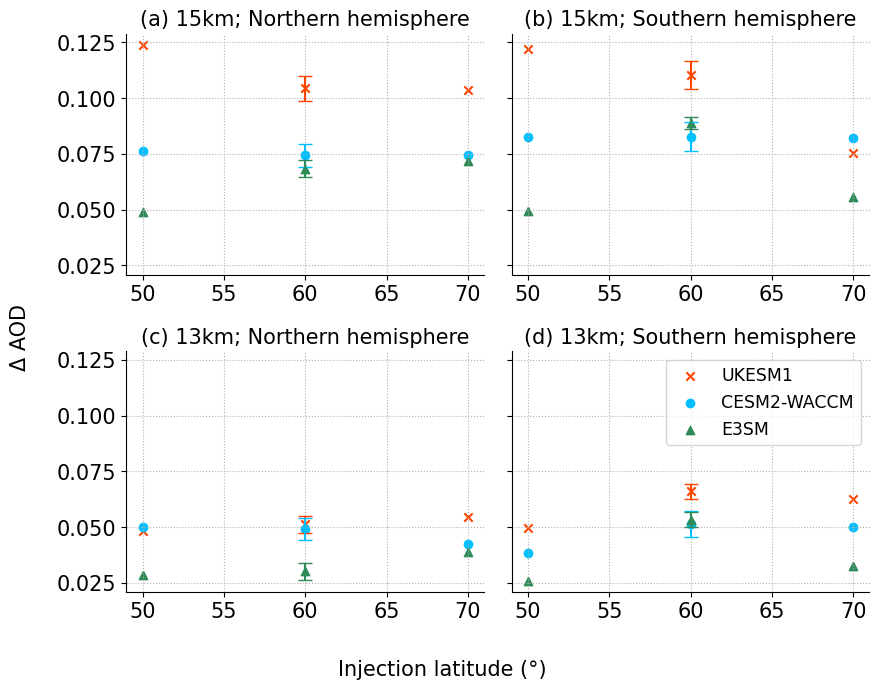

In [7]:
fig, axs =  plt.subplots(2, 2, figsize=(9, 7), sharey=True)

NH_background_aod = {'UKESM':NH_background_aod_UK,
                     'CESM':NH_background_aod_CE,
                     'E3SM':NH_background_aod_E3}

SH_background_aod = {'UKESM':SH_background_aod_UK,
                     'CESM':SH_background_aod_CE,
                     'E3SM':SH_background_aod_E3}

model_markers = {'UKESM':'x', 'CESM':'o', 'E3SM':'^'}

for ax in axs.flatten():
    ax.grid(ls='dotted')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
for run, lat in zip(['u-dj993', 'u-dk092', 'u-dk163'], [60, 70, 50]):
    for model in ['UKESM', 'CESM', 'E3SM']:
        aod_NH, aod_SH = get_hemispheric_means(get_AOD(run, model=model))
        aod_NH, aod_SH = aod_NH.mean('time').AOD550.values.item(), aod_SH.mean('time').AOD550.values.item()
        aod_delta_NH, aod_delta_SH = aod_NH - NH_background_aod[model], aod_SH - SH_background_aod[model]
        print(lat, model, aod_delta_NH, aod_delta_SH)
        axs.flatten()[2].scatter(lat, aod_delta_NH, marker=model_markers[model], color=dark_model_colors[model])
        axs.flatten()[3].scatter(lat, aod_delta_SH, marker=model_markers[model], color=dark_model_colors[model])
        if run == 'u-dj993':
            axs.flatten()[2].errorbar(lat, aod_delta_NH, yerr=stds_13_NH[model], color=dark_model_colors[model], capsize=5)
            axs.flatten()[3].errorbar(lat, aod_delta_SH, yerr=stds_13_SH[model], color=dark_model_colors[model], capsize=5)
    

for run, lat in zip(['u-dk035', 'u-dk101', 'u-dk164'], [60, 70, 50]):
    for model in ['UKESM', 'CESM', 'E3SM']:
        aod_NH, aod_SH = get_hemispheric_means(get_AOD(run, model=model))
        aod_NH, aod_SH = aod_NH.mean('time').AOD550.values.item(), aod_SH.mean('time').AOD550.values.item()
        aod_delta_NH, aod_delta_SH = aod_NH - NH_background_aod[model], aod_SH - SH_background_aod[model]
        print(lat, model, aod_delta_NH, aod_delta_SH)
        axs.flatten()[0].scatter(lat, aod_delta_NH, marker=model_markers[model], color=dark_model_colors[model])
        axs.flatten()[1].scatter(lat, aod_delta_SH, marker=model_markers[model], color=dark_model_colors[model])
        if run == 'u-dk035':
            axs.flatten()[0].errorbar(lat, aod_delta_NH, yerr=stds_15_NH[model], color=dark_model_colors[model], capsize=5)
            axs.flatten()[1].errorbar(lat, aod_delta_SH, yerr=stds_15_SH[model], color=dark_model_colors[model], capsize=5)
       
l = 3
axs.flatten()[l].scatter([], [], marker=model_markers['UKESM'], color=dark_model_colors['UKESM'], label='UKESM1')
axs.flatten()[l].scatter([], [], marker=model_markers['CESM'], color=dark_model_colors['CESM'], label='CESM2-WACCM')
axs.flatten()[l].scatter([], [], marker=model_markers['E3SM'], color=dark_model_colors['E3SM'], label='E3SM')
axs.flatten()[l].legend(fontsize='small')

axs.flatten()[0].set_title('(a) 15km; Northern hemisphere', fontsize='medium')
axs.flatten()[1].set_title('(b) 15km; Southern hemisphere', fontsize='medium')
axs.flatten()[2].set_title('(c) 13km; Northern hemisphere', fontsize='medium')
axs.flatten()[3].set_title('(d) 13km; Southern hemisphere', fontsize='medium')

fig.supylabel('\u0394 AOD', fontsize='medium')
#fig.suptitle('Sensitivity of hemispheric mean \u0394 AOD to inj. latitude')
#axs.flatten()[0].set_ylabel('15km\ninj.', rotation=0, labelpad=50)
#axs.flatten()[2].set_ylabel('13km\ninj.', rotation=0, labelpad=50)
fig.supxlabel('Injection latitude (°)', fontsize='medium')

    #ax.set_ylim(0, None)
plt.tight_layout()

plt.savefig('Figures/AODs_overview.jpg', dpi=300, bbox_inches='tight')



In [8]:
print((0.12395 - 0.1043767)/0.1043767)
print((0.04893 - 0.068452)/0.068452)

0.18752556844583132
-0.28519254368024305


In [9]:
print(0.103695/0.05137)

2.0185906170916876


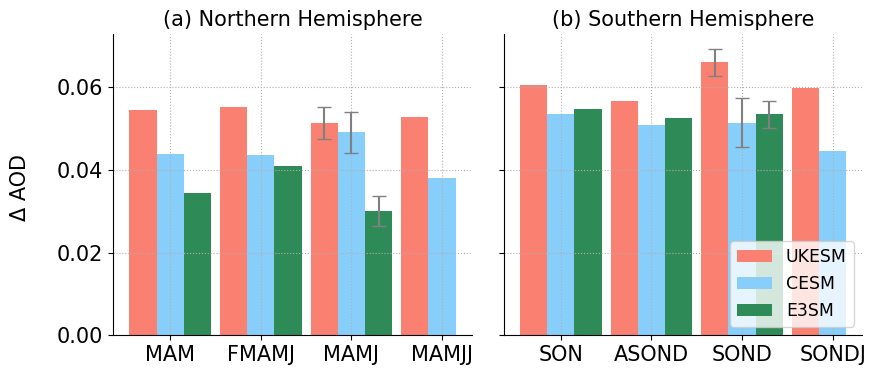

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

SH_seasons = ['SON', 'ASOND', 'SOND', 'SONDJ']
run_seasons = ['MAM', 'FMAMJ', 'MAMJ', 'MAMJJ']

bar_width = 0.3  # Width of the bars
x = np.arange(len(run_seasons))  # The label locations

stds = {'NH':stds_13_NH, 'SH':stds_13_SH}

for j, hemi in enumerate(['NH', 'SH']):
    for i, model in enumerate(['UKESM', 'CESM', 'E3SM']):
        values = []
        for run in ['u-dn605', 'u-dn690', 'u-dj993', 'u-dn675']:
            try:
                aod_NH, aod_SH = get_hemispheric_means(get_AOD(run, model=model))
                aod_NH, aod_SH = aod_NH.mean('time').AOD550.values.item(), aod_SH.mean('time').AOD550.values.item()
                aod_delta = aod_NH - NH_background_aod[model] if hemi == 'NH' else aod_SH - SH_background_aod[model]
                values.append(aod_delta)
            except:
                values.append(np.nan)
        if model == 'UKESM':
            offset = -bar_width
        if model == 'CESM':
            offset = 0
        if model == 'E3SM':
            offset = bar_width 
        axs[j].bar(x + offset, values, width=bar_width, label=model, color=model_colors[model])
        axs[j].errorbar(2+offset, values[2], yerr=stds[hemi][model], color='gray', capsize=5) #dark_model_colors[model]
    
    axs[j].set_xticks(x)
    axs[j].set_xticklabels(run_seasons if hemi == 'NH' else SH_seasons)
    #axs[j].set_title(f"{'Northern' if hemi == 'NH' else 'Southern'} Hemisphere", fontsize='medium')
    axs[j].grid(ls='dotted')
    axs[j].spines['top'].set_visible(False)
    axs[j].spines['right'].set_visible(False)

axs[0].set_title('(a) Northern Hemisphere', fontsize='medium')
axs[1].set_title('(b) Southern Hemisphere', fontsize='medium')
fig.supylabel('\u0394 AOD', fontsize='medium')
#fig.suptitle('Sensitivity of hemispheric mean \u0394 AOD to inj. season')
axs[1].legend(loc='lower right', fontsize='small')
plt.tight_layout()

plt.savefig('Figures/AODs_seasonality_grouped.jpg', dpi=300, bbox_inches='tight')


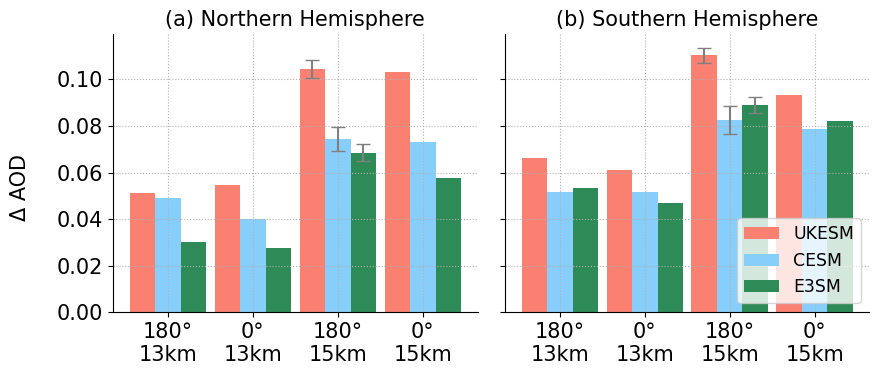

In [11]:
### longitude

fig, axs = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

locs = ['180°\n13km', '0°\n13km', '180°\n15km', '0°\n15km']

bar_width = 0.3  # Width of the bars
x = np.arange(len(locs))  # The label locations

for j, hemi in enumerate(['NH', 'SH']):
    for i, model in enumerate(['UKESM', 'CESM', 'E3SM']):
        values = []
        for run in ['u-dj993', 'u-dn757', 'u-dk035', 'u-dn758']:
            aod_NH, aod_SH = get_hemispheric_means(get_AOD(run, model=model))
            aod_NH, aod_SH = aod_NH.mean('time').AOD550.values.item(), aod_SH.mean('time').AOD550.values.item()
            aod_delta = aod_NH - NH_background_aod[model] if hemi == 'NH' else aod_SH - SH_background_aod[model]
            values.append(aod_delta)

        if model == 'UKESM':
            offset = -bar_width
        if model == 'CESM':
            offset = 0
        if model == 'E3SM':
            offset = bar_width 
        axs[j].bar(x + offset, values, width=bar_width, label=model, color=model_colors[model])
        axs[j].errorbar(2+offset, values[2], yerr=stds[hemi][model], color='gray', capsize=5)
        
    axs[j].set_xticks(x)
    axs[j].set_xticklabels(locs)
    #axs[j].set_title(f"{'Northern' if hemi == 'NH' else 'Southern'} Hemisphere", fontsize='medium')
    axs[j].grid(ls='dotted')
    axs[j].spines['top'].set_visible(False)
    axs[j].spines['right'].set_visible(False)

axs[0].set_title('(a) Northern Hemisphere', fontsize='medium')
axs[1].set_title('(b) Southern Hemisphere', fontsize='medium')

fig.supylabel('\u0394 AOD', fontsize='medium')
#fig.suptitle('Sensitivity of hemispheric mean \u0394 AOD to inj. longitude')
axs[1].legend(loc='lower right', fontsize='small')
plt.tight_layout()


plt.savefig('Figures/AODs_longitude.jpg', dpi=300, bbox_inches='tight')

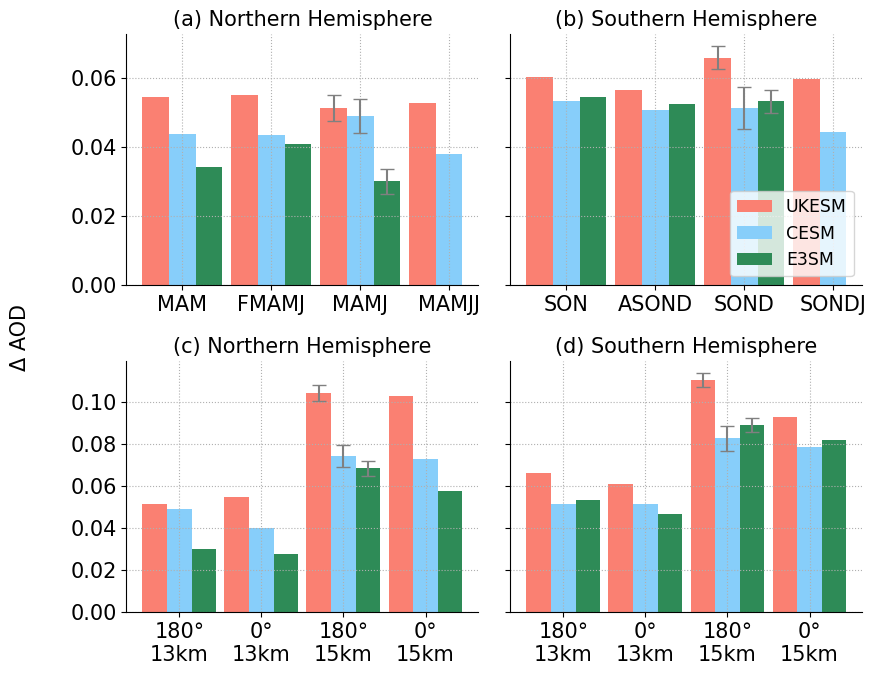

In [12]:
### combine the two above into one: 

### longitude

fig, axs = plt.subplots(2, 2, figsize=(9, 7), sharey='row')

locs = ['180°\n13km', '0°\n13km', '180°\n15km', '0°\n15km']

bar_width = 0.3  # Width of the bars
x = np.arange(len(locs))  # The label locations

k = 0 

for hemi in ['NH', 'SH']:
    ax = axs.flatten()[k]
    for i, model in enumerate(['UKESM', 'CESM', 'E3SM']):
        values = []
        for run in ['u-dn605', 'u-dn690', 'u-dj993', 'u-dn675']:
            try:
                aod_NH, aod_SH = get_hemispheric_means(get_AOD(run, model=model))
                aod_NH, aod_SH = aod_NH.mean('time').AOD550.values.item(), aod_SH.mean('time').AOD550.values.item()
                aod_delta = aod_NH - NH_background_aod[model] if hemi == 'NH' else aod_SH - SH_background_aod[model]
                values.append(aod_delta)
            except:
                values.append(np.nan)
        if model == 'UKESM':
            offset = -bar_width
        if model == 'CESM':
            offset = 0
        if model == 'E3SM':
            offset = bar_width 
        ax.bar(x + offset, values, width=bar_width, label=model, color=model_colors[model])
        ax.errorbar(2+offset, values[2], yerr=stds[hemi][model], color='gray', capsize=5) #dark_model_colors[model]
    
    ax.set_xticks(x)
    ax.set_xticklabels(run_seasons if hemi == 'NH' else SH_seasons)
    #axs[j].set_title(f"{'Northern' if hemi == 'NH' else 'Southern'} Hemisphere", fontsize='medium')
    ax.grid(ls='dotted')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    k = k+1

for hemi in ['NH', 'SH']:
    ax = axs.flatten()[k]
    for i, model in enumerate(['UKESM', 'CESM', 'E3SM']):
        values = []
        for run in ['u-dj993', 'u-dn757', 'u-dk035', 'u-dn758']:
            aod_NH, aod_SH = get_hemispheric_means(get_AOD(run, model=model))
            aod_NH, aod_SH = aod_NH.mean('time').AOD550.values.item(), aod_SH.mean('time').AOD550.values.item()
            aod_delta = aod_NH - NH_background_aod[model] if hemi == 'NH' else aod_SH - SH_background_aod[model]
            values.append(aod_delta)

        if model == 'UKESM':
            offset = -bar_width
        if model == 'CESM':
            offset = 0
        if model == 'E3SM':
            offset = bar_width 
        ax.bar(x + offset, values, width=bar_width, label=model, color=model_colors[model])
        ax.errorbar(2+offset, values[2], yerr=stds[hemi][model], color='gray', capsize=5)
    
    
    ax.set_xticks(x)
    ax.set_xticklabels(locs)
    #axs[j].set_title(f"{'Northern' if hemi == 'NH' else 'Southern'} Hemisphere", fontsize='medium')
    ax.grid(ls='dotted')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    k = k+1

axs.flatten()[0].set_title('(a) Northern Hemisphere', fontsize='medium')
axs.flatten()[1].set_title('(b) Southern Hemisphere', fontsize='medium')
axs.flatten()[2].set_title('(c) Northern Hemisphere', fontsize='medium')
axs.flatten()[3].set_title('(d) Southern Hemisphere', fontsize='medium')

fig.supylabel('\u0394 AOD', fontsize='medium')
#fig.suptitle('Sensitivity of hemispheric mean \u0394 AOD to inj. longitude')
axs.flatten()[1].legend(loc='lower right', fontsize='small')
plt.tight_layout()


plt.savefig('Figures/AODs_longitude_seasonality_combined.jpg', dpi=300, bbox_inches='tight')